In [1]:
import os
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

2026-06-10 14:25:42.272189: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-10 14:25:42.657280: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781119542.676095 1047327 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781119542.681742 1047327 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781119542.696402 1047327 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
def get_single_df(log_base_path, min_step=None, max_step=None):
    log_path = os.path.join(log_base_path, 'crossq_env*', 'events.out.tfevents*')
    data = []
    logs = glob.glob(log_path)
    for log in logs:
        folder_name = os.path.basename(os.path.dirname(log))  # crossq_env1
        parts = folder_name.split('_')
        algorithm = parts[0]
        env_id = parts[1]
        for e in tf.compat.v1.train.summary_iterator(log):
            for v in e.summary.value:
                if v.tag in ['rollout/ep_rew_mean', 'rollout/ep_len_mean']:
                    data.append({
                        'algorithm': algorithm,
                        'env': env_id,
                        'step': e.step,
                        'metric': v.tag,
                        'value': v.simple_value
                    })
    df = pd.DataFrame(data)
    if min_step is not None:
        df = df[df['step'] >= min_step]
    if max_step is not None:
        df = df[df['step'] <= max_step]
    if df.empty:
        print("No data available after filtering. Check your step range.")
        return
    return df

def plot_single_envs(df, p_title):
    plt.rcParams.update({'font.size': 14})
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
    # ---- Subplot 1: Reward ----
    ax = axes[0]
    df_rew = df[df['metric'] == 'rollout/ep_rew_mean']
    for env_id, env_df in df_rew.groupby('env'):
        env_df = env_df.sort_values('step')
        ax.plot(env_df['step'], env_df['value'], label=env_id, linewidth=2)
    ax.set_xlabel("Step")
    ax.set_ylabel("Reward")
    ax.set_title(f"Reward ({p_title})")
    ax.grid(True)
    ax.legend(loc='best', ncol=2)
    # ---- Subplot 2: Episode Length ----
    ax = axes[1]
    df_len = df[df['metric'] == 'rollout/ep_len_mean']
    for env_id, env_df in df_len.groupby('env'):
        env_df = env_df.sort_values('step')
        ax.plot(env_df['step'], env_df['value'], label=env_id, linewidth=2)
    ax.set_xlabel("Step")
    ax.set_ylabel("Episode Length")
    ax.set_title(f"Episode Length ({p_title})")
    ax.grid(True)
    ax.legend(loc='best', ncol=2)
    plt.tight_layout()
    plt.show()

Instructions for updating:
Use eager execution and: 
`tf.data.TFRecordDataset(path)`


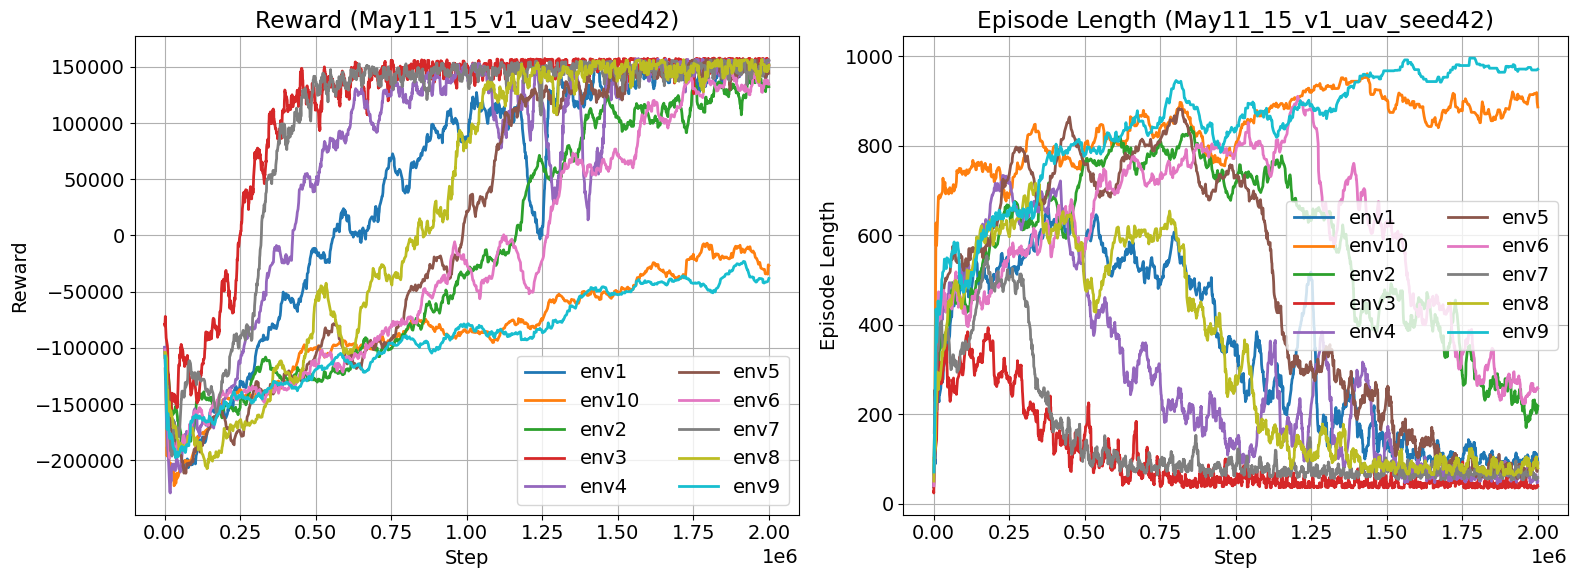

In [3]:
p_title = 'May11_15_v1_uav_seed42'
log_base_path = os.path.join('.', 'logs', p_title) # Set the path for the experiments
single_df = get_single_df(log_base_path)
plot_single_envs(single_df, p_title)

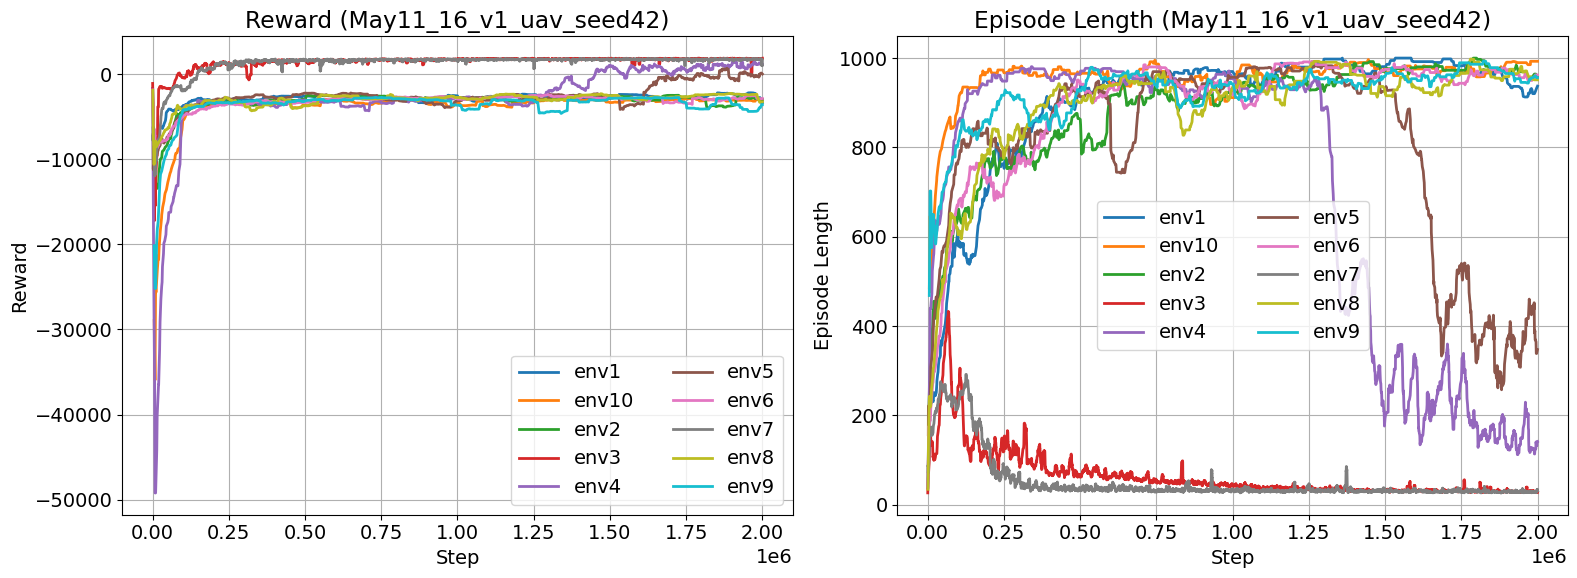

In [4]:
p_title = 'May11_16_v1_uav_seed42'
log_base_path = os.path.join('.', 'logs', p_title) # Set the path for the experiments
single_df = get_single_df(log_base_path)
plot_single_envs(single_df, p_title)

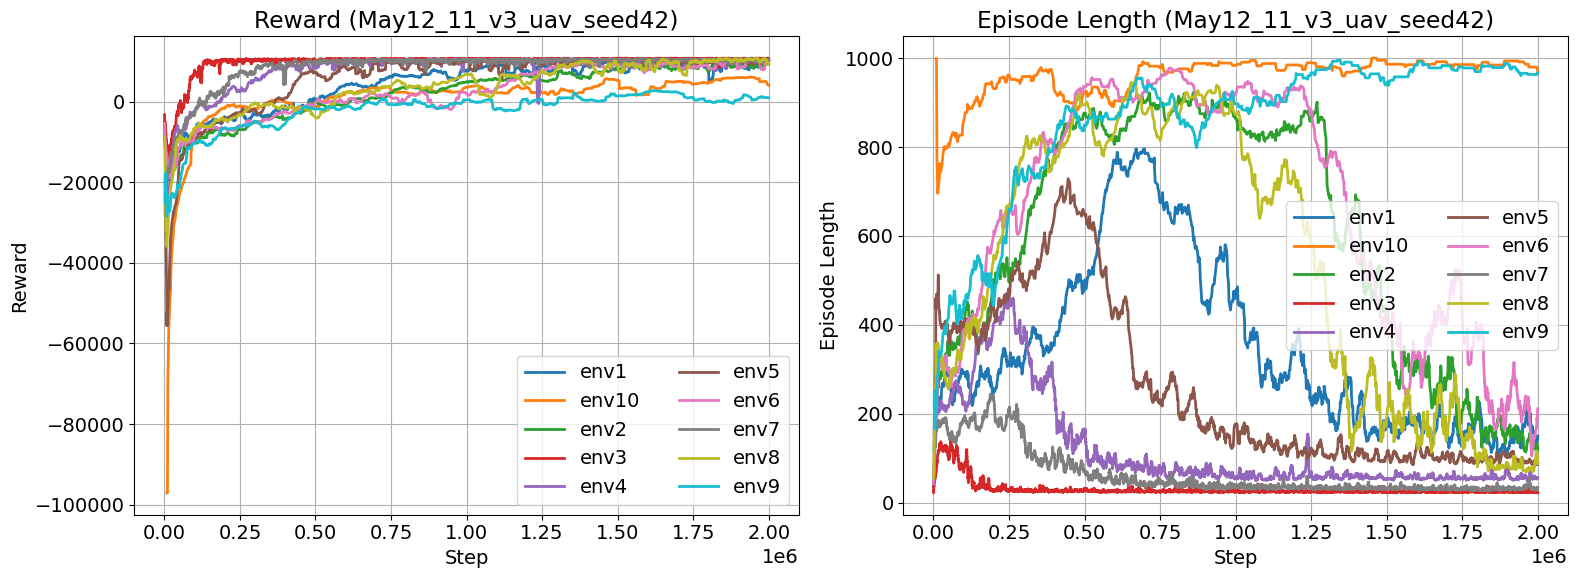

In [5]:
p_title = 'May12_11_v3_uav_seed42'
log_base_path = os.path.join('.', 'logs', p_title) # Set the path for the experiments
single_df = get_single_df(log_base_path)
plot_single_envs(single_df, p_title)

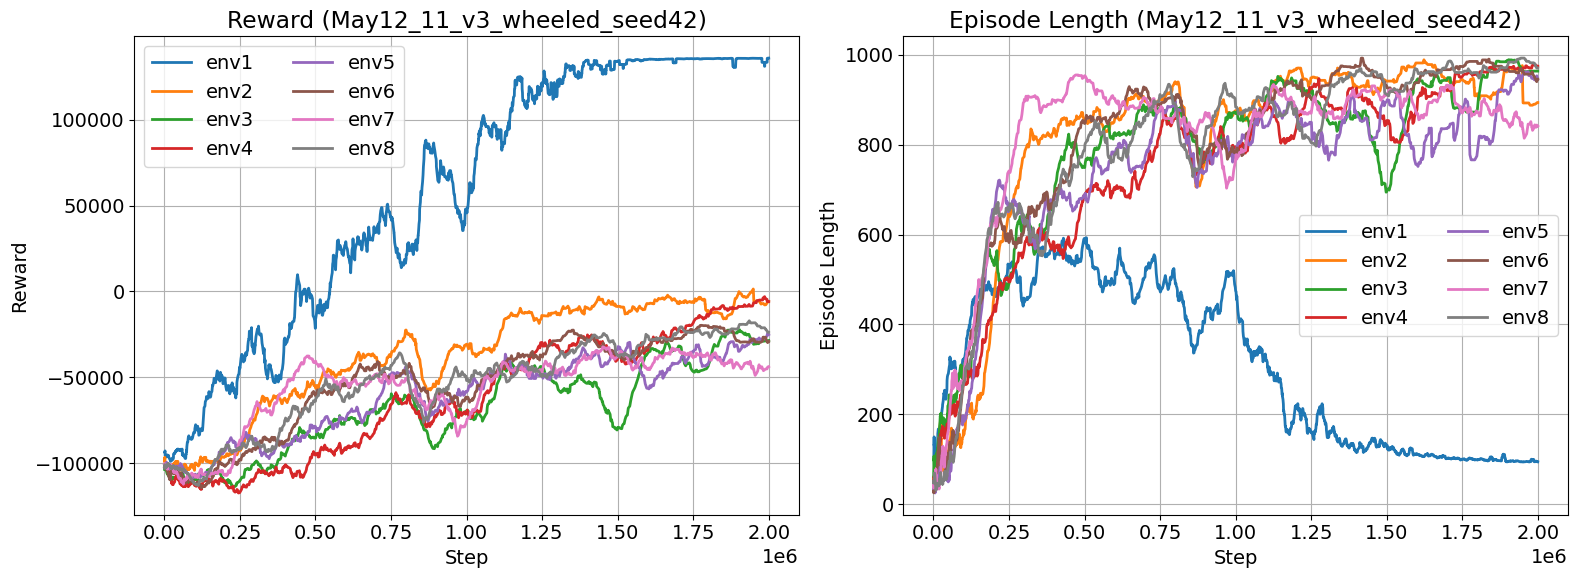

In [6]:
p_title = 'May12_11_v3_wheeled_seed42'
log_base_path = os.path.join('.', 'logs', p_title) # Set the path for the experiments
single_df = get_single_df(log_base_path)
plot_single_envs(single_df, p_title)

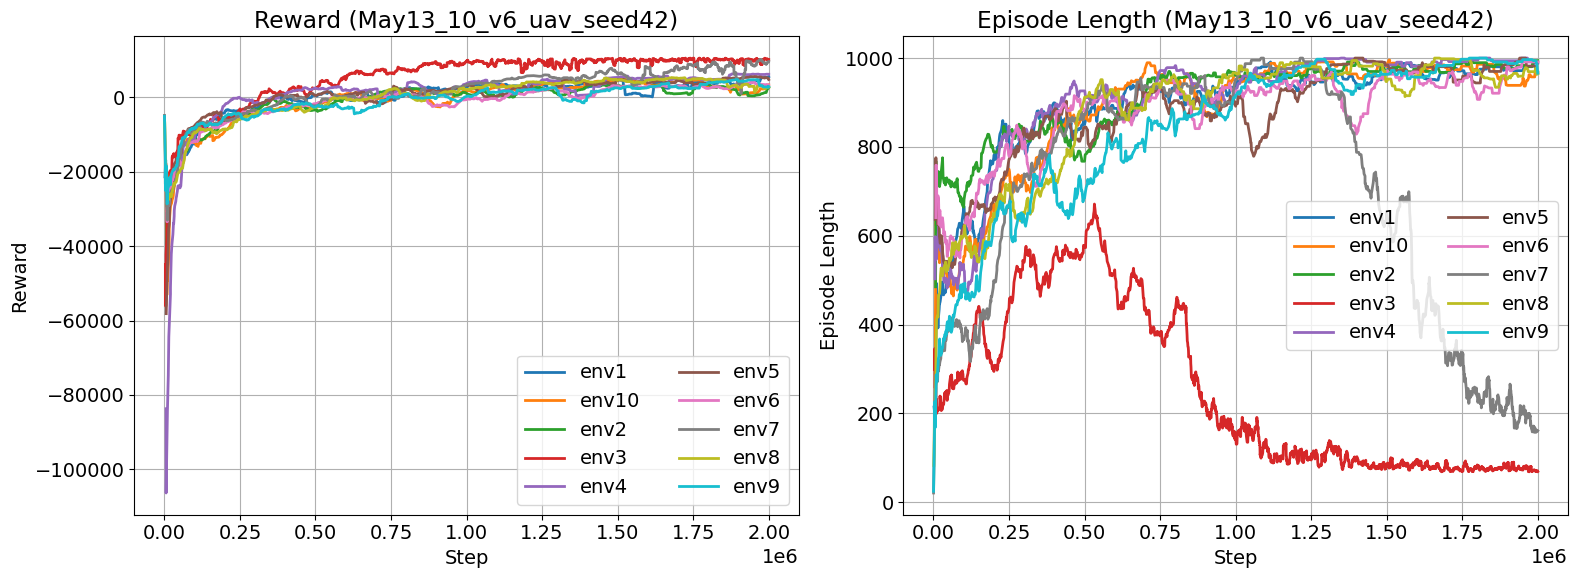

In [7]:
p_title = 'May13_10_v6_uav_seed42'
log_base_path = os.path.join('.', 'logs', p_title) # Set the path for the experiments
single_df = get_single_df(log_base_path)
plot_single_envs(single_df, p_title)

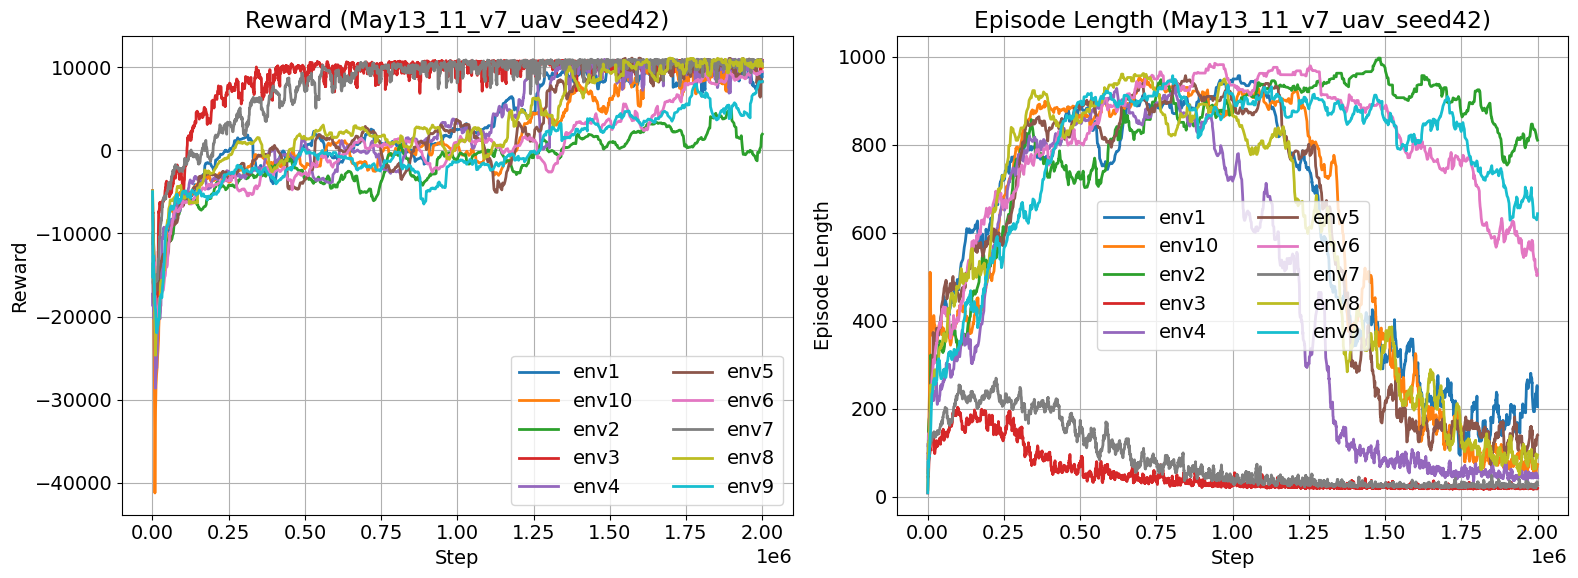

In [8]:
p_title = 'May13_11_v7_uav_seed42'
log_base_path = os.path.join('.', 'logs', p_title) # Set the path for the experiments
single_df = get_single_df(log_base_path)
plot_single_envs(single_df, p_title)

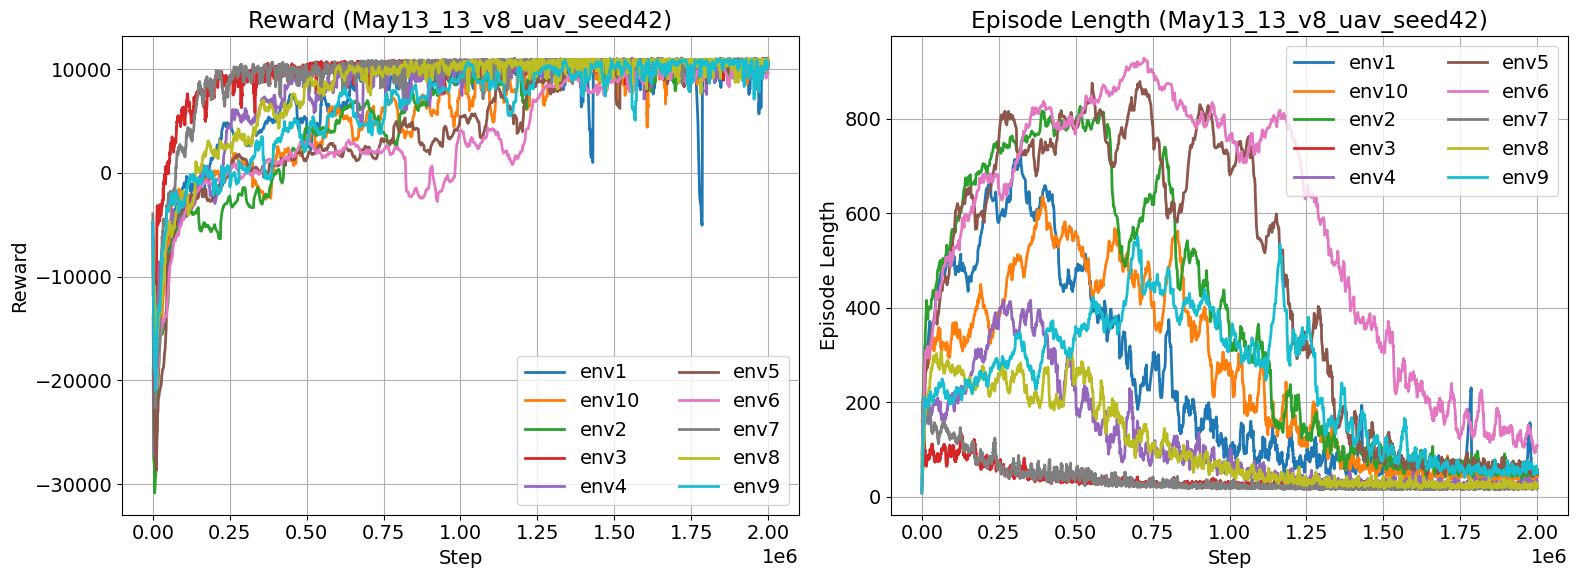

In [9]:
p_title = 'May13_13_v8_uav_seed42'
log_base_path = os.path.join('.', 'logs', p_title) # Set the path for the experiments
single_df = get_single_df(log_base_path)
plot_single_envs(single_df, p_title)

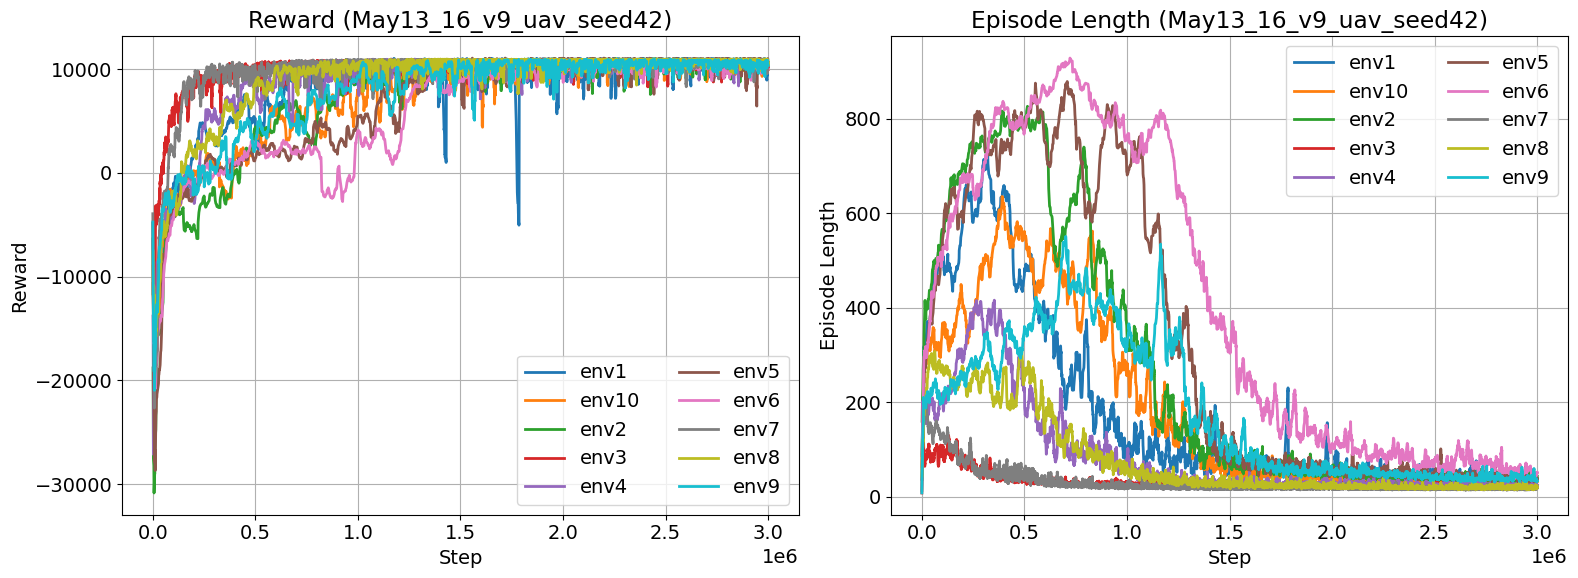

In [10]:
p_title = 'May13_16_v9_uav_seed42'
log_base_path = os.path.join('.', 'logs', p_title) # Set the path for the experiments
single_df = get_single_df(log_base_path)
plot_single_envs(single_df, p_title)

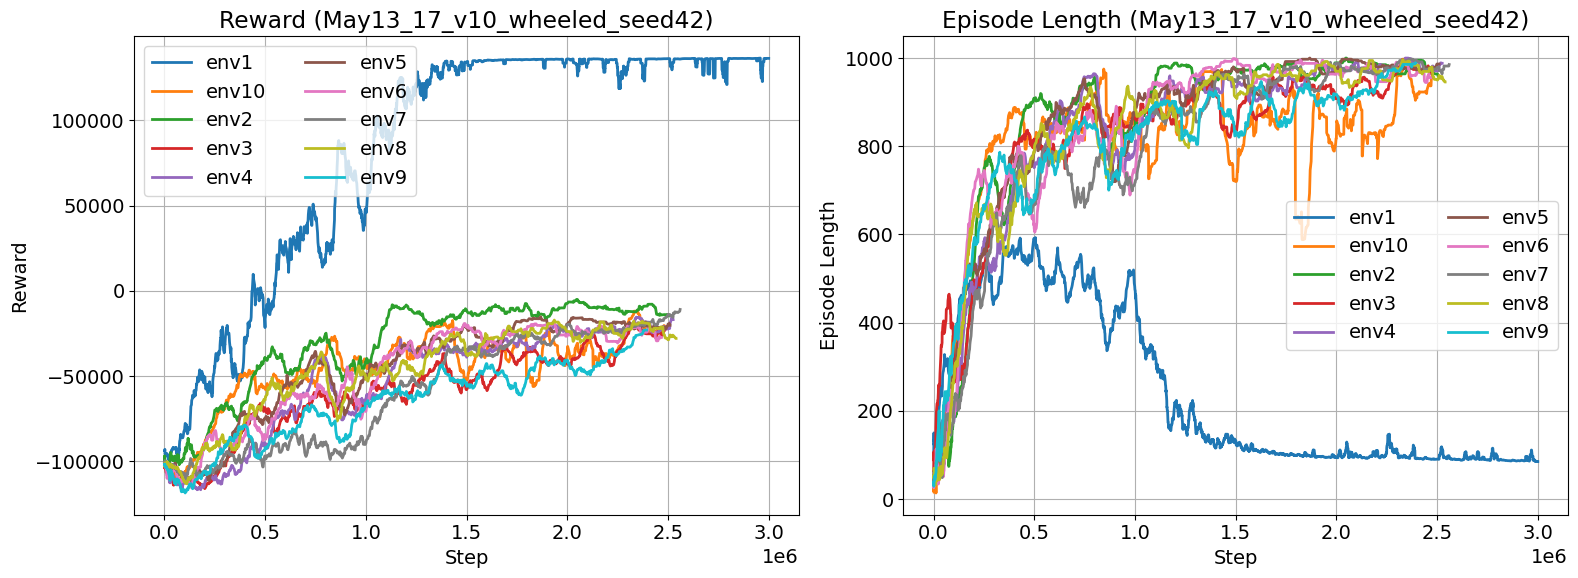

In [11]:
p_title = 'May13_17_v10_wheeled_seed42'
log_base_path = os.path.join('.', 'logs', p_title) # Set the path for the experiments
single_df = get_single_df(log_base_path)
plot_single_envs(single_df, p_title)

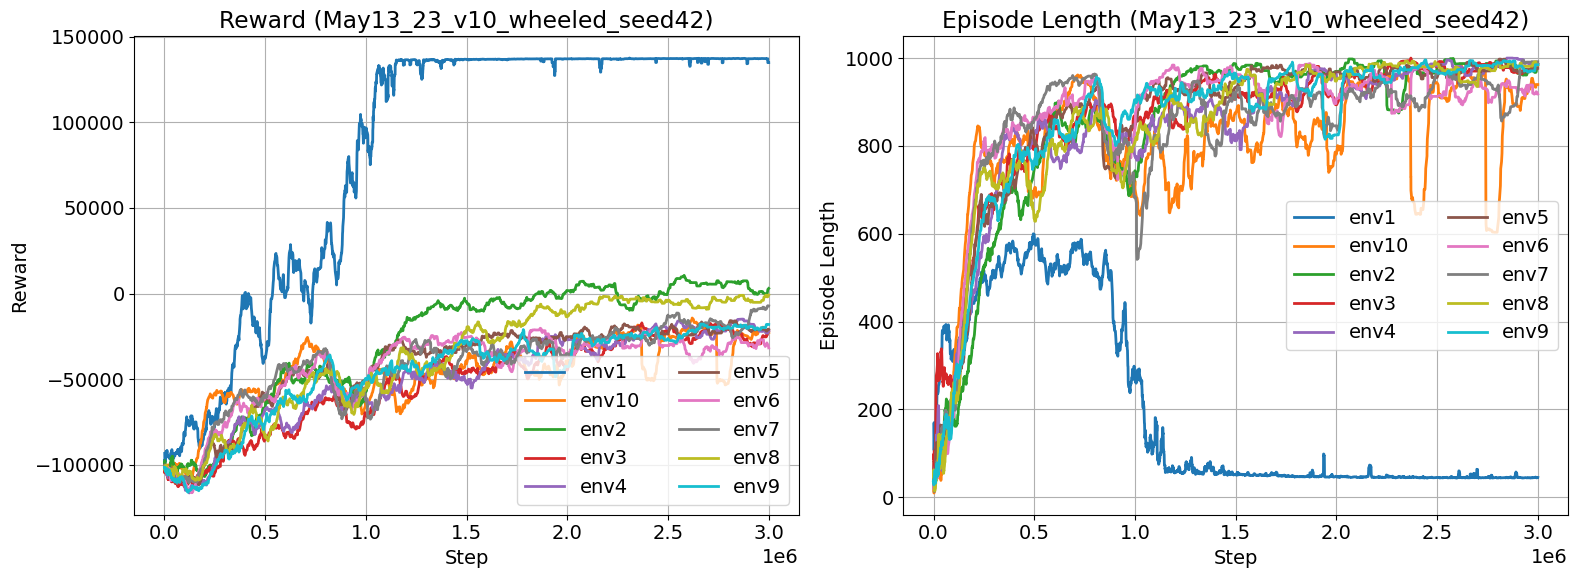

In [12]:
p_title = 'May13_23_v10_wheeled_seed42'
log_base_path = os.path.join('.', 'logs', p_title) # Set the path for the experiments
single_df = get_single_df(log_base_path)
plot_single_envs(single_df, p_title)

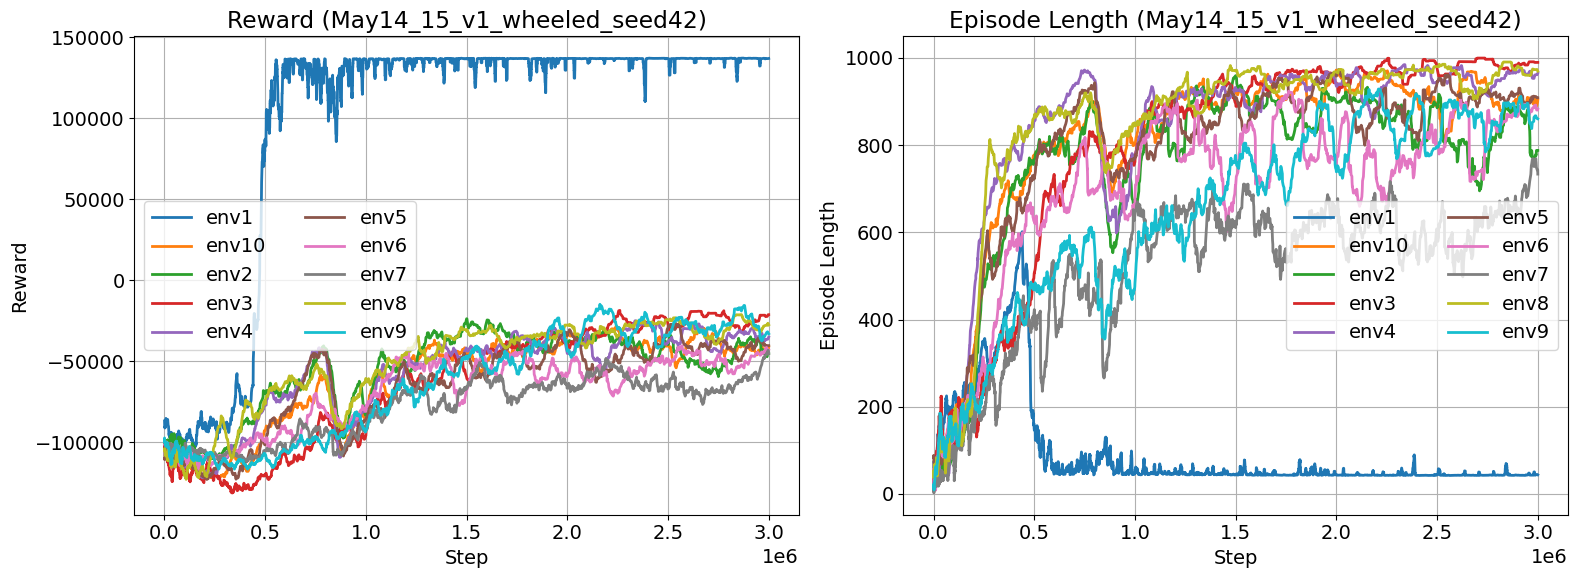

In [13]:
p_title = 'May14_15_v1_wheeled_seed42'
log_base_path = os.path.join('.', 'logs', p_title) # Set the path for the experiments
single_df = get_single_df(log_base_path)
plot_single_envs(single_df, p_title)

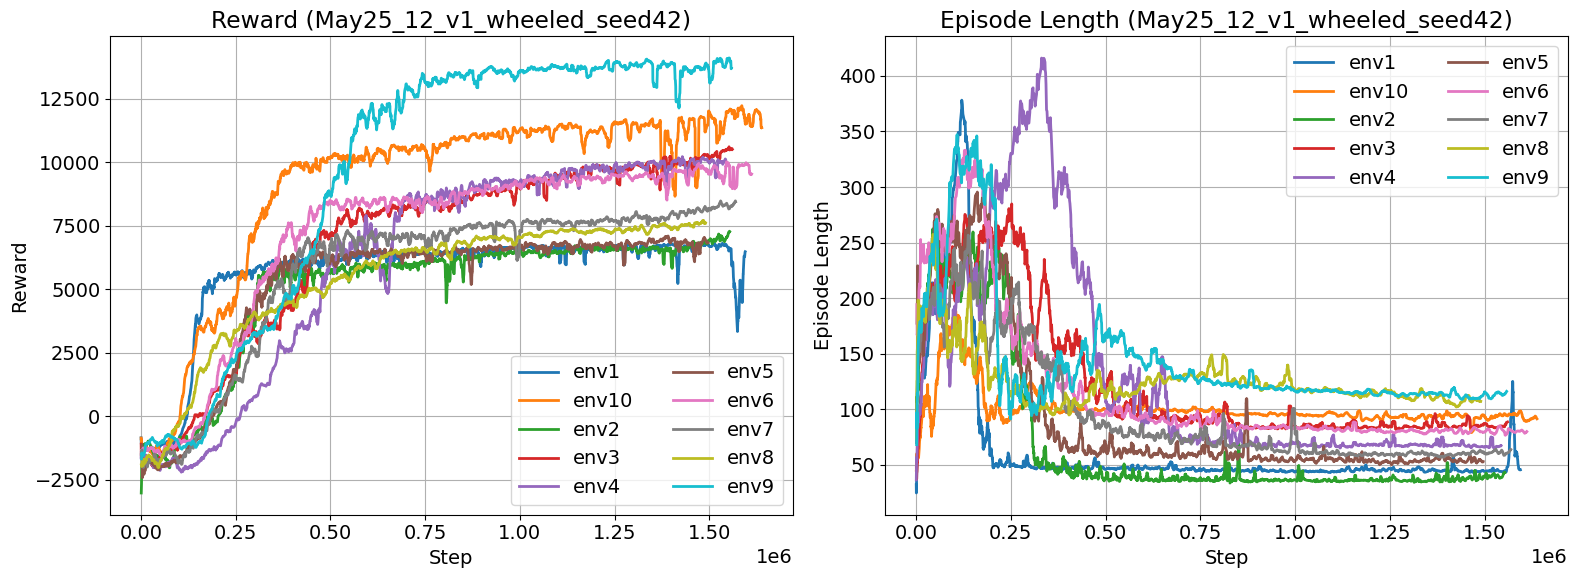

In [14]:
p_title = 'May25_12_v1_wheeled_seed42'
log_base_path = os.path.join('.', 'logs', p_title) # Set the path for the experiments
single_df = get_single_df(log_base_path)
plot_single_envs(single_df, p_title)

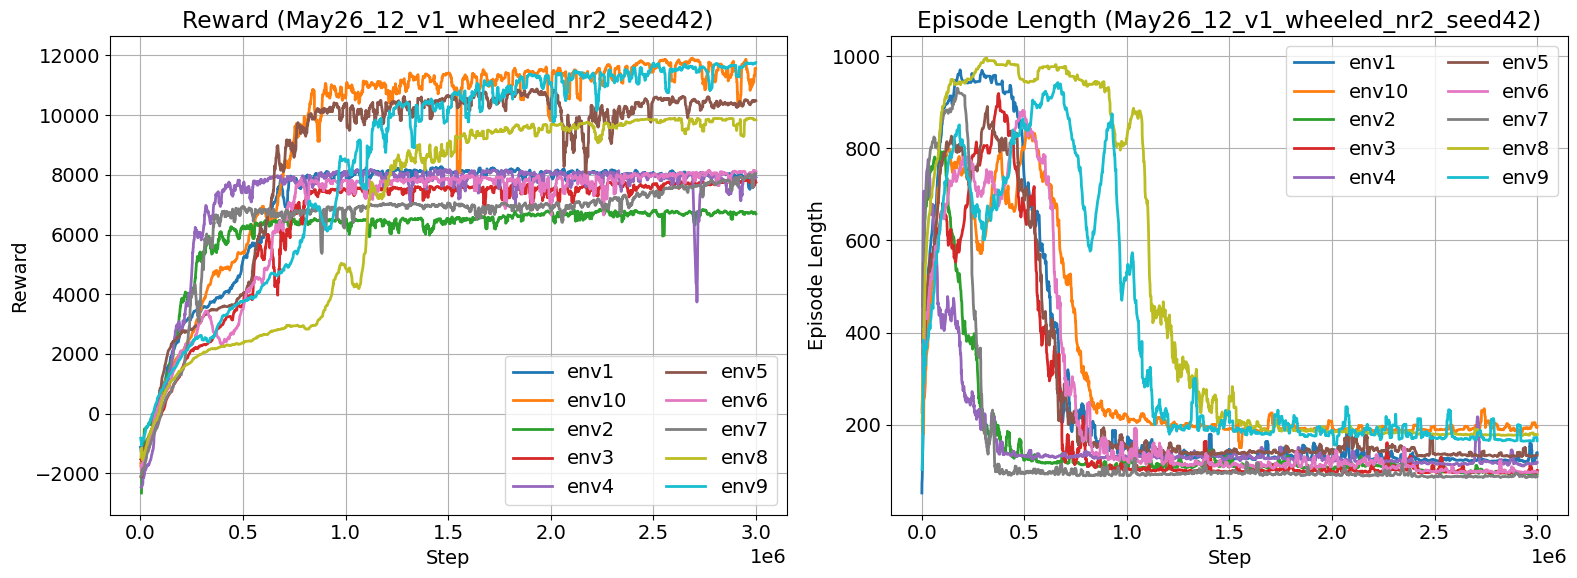

In [15]:
p_title = 'May26_12_v1_wheeled_nr2_seed42'
log_base_path = os.path.join('.', 'logs', p_title) # Set the path for the experiments
single_df = get_single_df(log_base_path)
plot_single_envs(single_df, p_title)

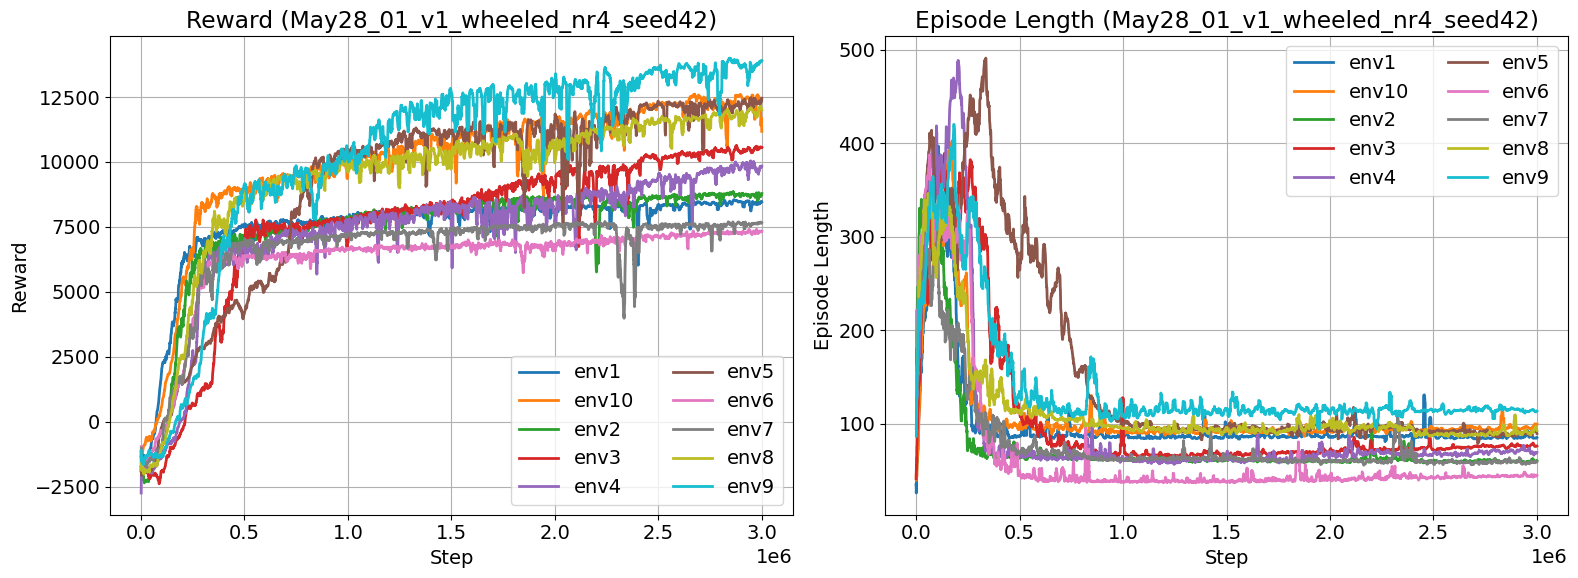

In [18]:
p_title = 'May28_01_v1_wheeled_nr4_seed42'
log_base_path = os.path.join('.', 'logs', p_title) # Set the path for the experiments
single_df = get_single_df(log_base_path)
plot_single_envs(single_df, p_title)

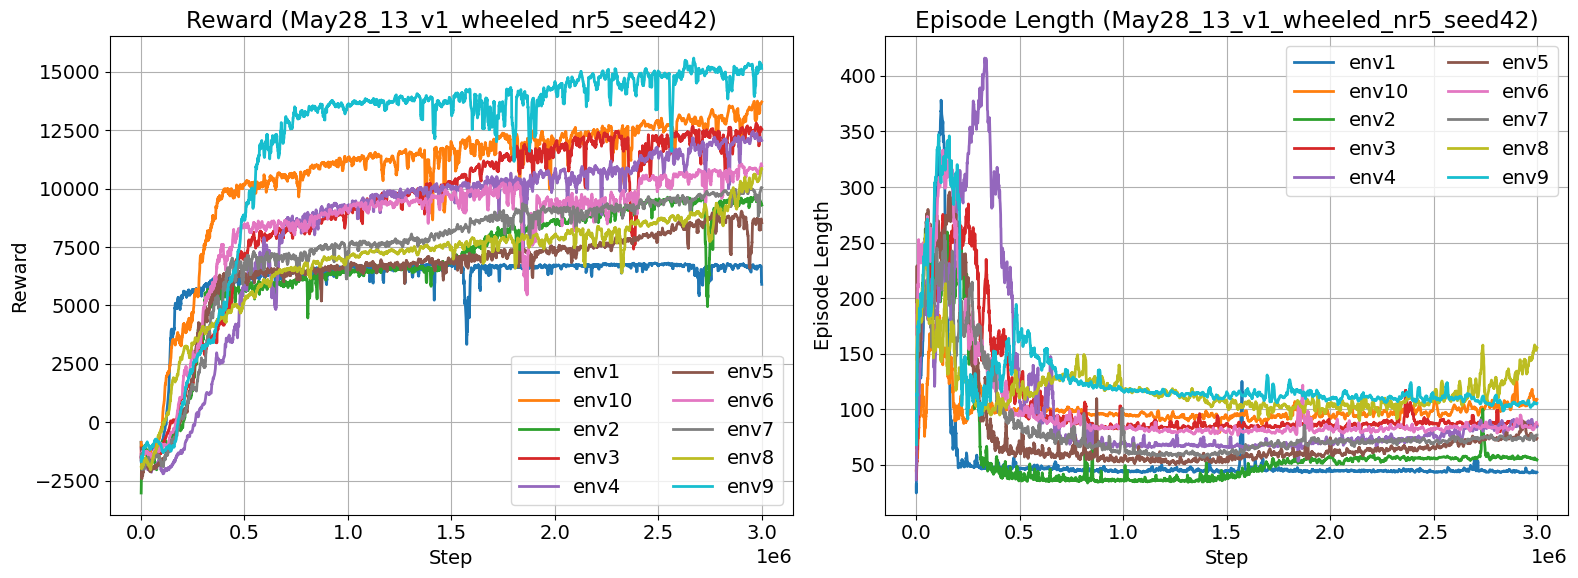

In [19]:
p_title = 'May28_13_v1_wheeled_nr5_seed42'
log_base_path = os.path.join('.', 'logs', p_title) # Set the path for the experiments
single_df = get_single_df(log_base_path)
plot_single_envs(single_df, p_title)

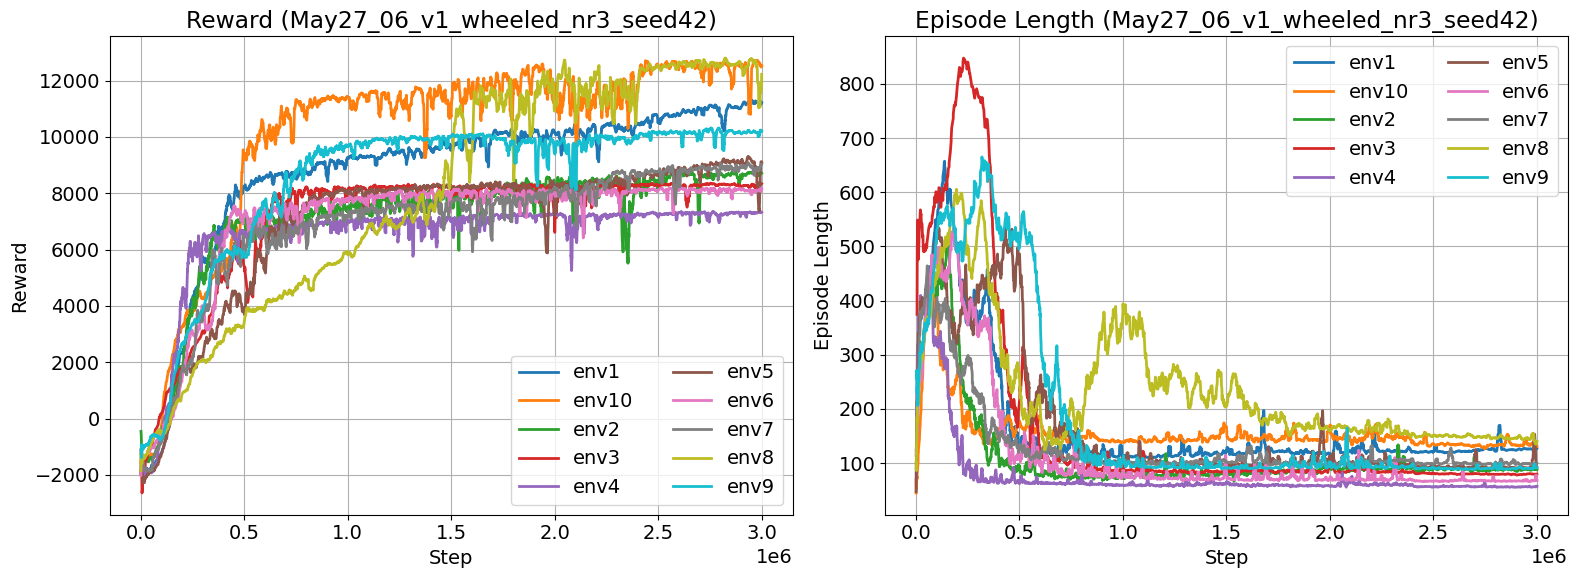

In [20]:
p_title = 'May27_06_v1_wheeled_nr3_seed42'
log_base_path = os.path.join('.', 'logs', p_title) # Set the path for the experiments
single_df = get_single_df(log_base_path)
plot_single_envs(single_df, p_title)

In [16]:
def get_multiple_df(method_paths, min_step=None, max_step=None):
    data = []
    for method_path in method_paths:
        logs = glob.glob(method_path)
        for log in logs:
            if "events.out.tfevents" not in log:
                continue
            parts = log.split(os.sep)
            experiment_info = parts[-2].split('_')
            algorithm = experiment_info[0]
            st = experiment_info[1]

            method_name = method_path.split(os.sep)[2]

            for e in tf.compat.v1.train.summary_iterator(log):
                for v in e.summary.value:
                    if v.tag in ['rollout/ep_rew_mean', 'rollout/ep_len_mean']:
                        data.append({
                            'method': method_name,
                            'algorithm': algorithm,
                            'set': st,
                            'step': e.step,
                            'metric': v.tag,
                            'value': v.simple_value
                        })
    df = pd.DataFrame(data)
    if min_step is not None:
        df = df[df['step'] >= min_step]
    if max_step is not None:
        df = df[df['step'] <= max_step]
    if df.empty:
        print("No data available after filtering. Check your step range.")
        return
    return df

def plot_methods_comparison(df, p_title):    
    min_step = df['step'].min()
    max_step = df['step'].max()
    common_steps = np.linspace(min_step, max_step, 200)
    plt.rcParams.update({'font.size': 12})
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
    metrics_info = [
        ('rollout/ep_rew_mean', 'Reward'),
        ('rollout/ep_len_mean', 'Episode Length')
    ]
    for ax, (metric_name, ylabel) in zip(axes, metrics_info):
        df_metric = df[df['metric'] == metric_name]
        # Group by method + algorithm
        for (method, algo), algo_df in df_metric.groupby(['method', 'algorithm']):
            runs = []
            for run_id, run_df in algo_df.groupby('set'):
                run_df = run_df.sort_values('step')
                x = run_df['step'].values
                y = run_df['value'].values
                if len(x) < 2:
                    continue
                interp_vals = np.interp(common_steps, x, y)
                runs.append(interp_vals)
            if len(runs) == 0:
                continue
            runs = np.array(runs)
            mean_vals = runs.mean(axis=0)
            std_vals = runs.std(axis=0)
            label = f"{method}-{algo}"
            ax.plot(common_steps, mean_vals, label=label, linewidth=2)
            ax.fill_between(common_steps,
                            mean_vals - std_vals,
                            mean_vals + std_vals,
                            alpha=0.2)
        ax.set_xlabel("Step")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{ylabel} ({p_title})")
        ax.grid(True)
        ax.legend(loc='best', fontsize=9)
    plt.tight_layout()
    plt.show()

In [17]:
ver_list = [r'Apr17_version_v3_1',
            r'Apr17_version_v8',
            r'Apr20_version_v1']
method_paths = [os.path.join('.', 'logs', ver, '*', '*') for ver in ver_list]
methods_df = get_multiple_df(method_paths)
plot_methods_comparison(methods_df, p_title='Method Comparison')

No data available after filtering. Check your step range.


TypeError: 'NoneType' object is not subscriptable

In [ ]:
def get_plateau_stats(df, min_step=None, max_step=None):
    df_filtered = df.copy()

    if min_step is not None:
        df_filtered = df_filtered[df_filtered['step'] >= min_step]
    if max_step is not None:
        df_filtered = df_filtered[df_filtered['step'] <= max_step]

    # ✅ STEP 1: mean per run (VERY IMPORTANT)
    run_means = (
        df_filtered.groupby(['method', 'algorithm', 'set', 'metric'])['value']
        .mean()
        .reset_index()
    )

    # ✅ STEP 2: aggregate across runs
    stats = (
        run_means.groupby(['method', 'metric'])['value']
        .agg(['mean', 'std', 'min', 'max'])
        .reset_index()
    )

    stats['range'] = stats['max'] - stats['min']
    stats = stats.sort_values(by='mean')

    return stats

In [ ]:
stats = get_plateau_stats(methods_df)
stats